# Baseline & Spectral Pollution

Setup: W0 (Zero Wind) + G1 (Square) and G2 (L-Shape).


### Required Libraries

In [122]:
import numpy as np       #numpy
import scipy.sparse as sp #sparse matrices
import matplotlib.pyplot as plt #matplot
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from firedrake import *
from netgen.occ import *
from ngsolve.webgui import Draw
import math

## Mesh Generation & Configuration

In [123]:
def make_Lshape_mesh(maxh=0.1):
    """
    Build the L-shaped domain and mesh it with Netgen.

    Parameters:
    maxh (float): maximum mesh size. No triangle edge will be longer than maxh.

    Returns:
    mesh: a Firedrake Mesh of the L-shaped domain.
    """
    # Axes((0,0,0), n=Z, h=X): Sets up a local coordinate system.
    #   - Origin is at (0,0,0).
    #   - Normal vector (n) is the Z-axis (meaning the plane is the XY-plane).
    #   - Horizontal axis (h) is the X-axis.
    # WorkPlane(...): Creates a 2D sketching plane using those axes.
    # Rectangle(1,2): Draws a rectangle from (0,0) to (1,2) on that plane.
    # Face(): Converts the hollow rectangle outline into a filled 2D surface.
    rect1 = WorkPlane(Axes((0, 0, 0), n=Z, h=X)).Rectangle(1, 2).Face()

    # Rectangle(2,1): Draws a rectangle from (0,0) to (2,1) on that plane.
    rect2 = WorkPlane(Axes((0, 0, 0), n=Z, h=X)).Rectangle(2, 1).Face()

    # join rect1 and rect2 together into a single continuous L-shaped 2D face,
    # automatically removing the overlapping internal edges.
    L = rect1 + rect2  # this is an OCC object

    # OCCGeometry(...): Wraps the OpenCascade shape (L) into a Netgen geometry object.
    # dim=2: Explicitly tells Netgen that this is a 2D surface geometry, not 3D.
    geo = OCCGeometry(L, dim=2)

    # GenerateMesh(...): Calls Netgen's meshing algorithm to divide the shape
    # into triangles.
    ngmsh = geo.GenerateMesh(maxh=maxh)

    # Mesh(...): Wraps the raw Netgen mesh into a Firedrake Mesh object.
    return Mesh(ngmsh)


def make_squareshape_mesh(maxh=0.1, side=1.0):
    """
    Build a square domain and mesh it with Netgen.

    The square has no reentrant corner, so it serves as the smooth-domain
    control against the L-shape.

    Parameters:
    maxh (float): maximum mesh size. No triangle edge will be longer than maxh.
    side (float): side length of the square.

    Returns:
    mesh: a Firedrake Mesh of the square domain.
    """
    # Same local coordinate system as the L-shape: origin at (0,0,0), normal
    # along Z so we sketch in the XY-plane, horizontal axis along X.
    # Rectangle(side, side): a square from (0,0) to (side,side).
    # Face(): Converts the hollow outline into a filled 2D surface.
    square = WorkPlane(Axes((0, 0, 0), n=Z, h=X)).Rectangle(side, side).Face()

    # OCCGeometry(...): Wraps the OpenCascade shape into a Netgen geometry object.
    # dim=2: Explicitly tells Netgen that this is a 2D surface geometry, not 3D.
    geo = OCCGeometry(square, dim=2)

    # GenerateMesh(...): Calls Netgen's meshing algorithm to divide the shape
    # into triangles.
    ngmsh = geo.GenerateMesh(maxh=maxh)

    # Mesh(...): Wraps the raw Netgen mesh into a Firedrake Mesh object.
    return Mesh(ngmsh)


### Test FE Spaces

Both formulations are stated for general $(n,k)$ and then specialised to $n=2$, $k=1$.

**1-forms in 2D.** Since $n-k = k = 1$, the Hodge star maps $\Lambda^1$ to itself. On
vector proxies it acts as the rotation $R\mathbf{v} = (-v_2, v_1)$, which satisfies
$\operatorname{div}(R\mathbf v) = -\operatorname{curl}\mathbf v$ and
$(R\mathbf v)\cdot\mathbf n = \mathbf v\cdot\mathbf t$. A 1-form in 2D therefore admits
*two* equivalent vector proxies, and the primal and dual complexes pick different ones:

$$H\Lambda^\bullet:\quad H^1 \xrightarrow{\ \mathrm d^0 = \nabla^\perp\ } H(\operatorname{div}) \xrightarrow{\ \mathrm d^1 = \operatorname{div}\ } L^2$$

$$H^*\Lambda^\bullet:\quad L^2 \xrightarrow{\ \delta^2 = \nabla\ } H(\operatorname{curl}) \xrightarrow{\ \delta^1 = \operatorname{curl}\ } H^1$$

At element level the two proxies of $\mathcal P^-_r\Lambda^1$ are Raviart--Thomas and
Nédélec first kind; those of $\mathcal P_r\Lambda^1$ are BDM and Nédélec second kind.
The $B$-formulation lives in the dual complex, so it is discretised with `N1curl`; the
$A$-formulation lives in the primal complex at $k-1=0$, so it is discretised with `CG`.

#### B-Formulation

Find $\lambda \in \mathbb{C}$ and $v \in \mathring{H}^*\Lambda^k(\Omega)$, $v \neq 0$,
such that for some $p \in \mathring{H}^*\Lambda^{k+1}(\Omega)$,

$$\begin{cases}
\varepsilon(\delta^k v, \delta^k w) + (\iota_\mathbf{u}^k v, \delta^k w) - (\delta^{k+1}p, w) = \lambda(v, w) &\forall w \in \mathring{H}^*\Lambda^k(\Omega) \\
(v, \delta^{k+1}q) = 0 &\forall q \in \mathring{H}^*\Lambda^{k+1}(\Omega)
\end{cases}$$

Note that both spaces carry the star as well as the ring: the essential condition is on
the *dual* trace $\operatorname{Tr}(\star\,\cdot) = 0$, which is what makes the boundary
terms in the derivation vanish.

For $n = 2$, $k = 1$: $\mathring{H}^*\Lambda^1 \cong H_0(\operatorname{curl};\Omega)$ with
$\delta^1 \cong \operatorname{curl}$, and $\mathring{H}^*\Lambda^2 \cong H^1_0(\Omega)$
with $\delta^2 \cong \nabla$. Writing $\iota_\mathbf{u}v \cong v \times \mathbf u$, the
problem reads: find $\lambda \in \mathbb C$, $v \in H_0(\operatorname{curl};\Omega)$,
$p \in H^1_0(\Omega)$ with

$$\begin{cases}
\varepsilon(\nabla\times v, \nabla\times w) + (v\times\mathbf u, \nabla\times w) - (\nabla p, w) = \lambda(v,w) &\forall w \in H_0(\operatorname{curl};\Omega)\\
(v, \nabla q) = 0 &\forall q \in H^1_0(\Omega)
\end{cases}$$

Discretised with $V_h = \mathcal P^-_r\Lambda^1 = $ `N1curl`$_r$ and
$Q_h = \mathcal P_r\Lambda^0 = $ `CG`$_r$, with essential conditions
$v \times \mathbf n = 0$ and $p = 0$ on $\partial\Omega$. The sign convention
$-(\nabla p, w)$ with $+(v,\nabla q)$ makes the pencil non-symmetric; taking $+$ in both
gives a symmetric saddle point and permits a Hermitian eigensolver when $\mathbf u = 0$.

#### A-Formulation

$(\lambda, \omega)$ satisfies the mixed formulation

$$\begin{cases}
\varepsilon(\mathrm{d}^{k-1}\omega, \mathrm{d}^{k-1}z) + (\iota_\mathbf{u}^k\mathrm{d}^{k-1}\omega, z) - (\mathrm{d}^{k-2}p, z) - (t,z) + \nu(\omega,z) = (\lambda + \nu)(\omega,z) &\forall z \in H\Lambda^{k-1}(\Omega) \quad\text{(a)}\\
(\omega, \mathrm{d}^{k-2}q) = 0 &\forall q \in H\Lambda^{k-2}(\Omega) \quad\text{(b)}\\
(\omega, s) = 0 &\forall s \in \mathcal{H}^{k-1}(\Omega) \quad\text{(c)}
\end{cases}$$

for some $p \in H\Lambda^{k-2}(\Omega)$ and $t \in \mathcal H^{k-1}(\Omega)$, with
$v = \mathrm d^{k-1}\omega$ recovering the eigenfunction of the $B$-formulation.

Specialising to $n = 2$, $k = 1$:

* $k-1 = 0$, so $H\Lambda^{0}(\Omega) = H^1(\Omega)$ — Lagrange elements. There is **no
  essential boundary condition**: the space carries no ring, and the trace condition
  $\varepsilon\,\partial_n\omega = 0$ arises naturally from (a).
* $\mathrm d^{0} \cong \nabla^\perp$ into the $H(\operatorname{div})$ proxy of
  $\Lambda^1$, equivalently $\nabla$ into the $H(\operatorname{curl})$ proxy used by the
  $B$-formulation. Either way $(\mathrm d^0\omega, \mathrm d^0 z) = (\nabla\omega,\nabla z)$,
  since $R$ is an isometry, and $\iota_\mathbf{u}\mathrm d^0\omega = \mathbf u\cdot\nabla\omega$.
  Note $v = \nabla^\perp\omega$ is divergence-free identically, so the constraint
  $\mathrm d^k v = 0$ holds by construction.
* $k-2 = -1$ and $\Lambda^{-1} = 0$, so $p$ and constraint (b) drop out. In particular the
  Coulomb gauge (b) is *vacuous* in 2D and imposes nothing on $\omega$.
* $\mathcal H^{k-1} = \mathcal H^{0}(\Omega) \cong H^0_{\mathrm{dR}}(\Omega) = \mathbb R$
  for connected $\Omega$. This is **not** trivial, for any domain, regardless of topology.
  Constraint (c) therefore survives and reads $\int_\Omega \omega = 0$, with multiplier
  $t \in \mathbb R$. The gauge freedom of a scalar potential is exactly the additive
  constant, and it is (c), not (b), that removes it.
* $\nu$ cancels between the two sides: it is a coercivity shift used in the analysis of the
  associated source problem and does not move the spectrum. We take $\nu = 0$.

The formulation thus reduces to: find $\lambda \in \mathbb C$, $\omega \in H^1(\Omega)$
with $\omega \neq 0$, and $t \in \mathbb R$ such that

$$\begin{cases}
\varepsilon(\nabla\omega, \nabla z) + (\mathbf u\cdot\nabla\omega, z) - (t, z) = \lambda(\omega, z) &\forall z \in H^1(\Omega)\\
(\omega, s) = 0 &\forall s \in \mathbb R
\end{cases}$$

discretised with $\Omega_h = \mathcal P_r\Lambda^0 = $ `CG`$_r$ and
$\mathcal H^0_h = \mathbb R$ (`R`, degree 0), which is the space of discrete harmonic
0-forms exactly, not an approximation of it. The degree is matched to the
$B$-formulation, since $\nabla(\mathcal P_r\Lambda^0) \subset \mathcal P^-_r\Lambda^1$.

**Baseline check.** With $\mathbf u = 0$, $\varepsilon = 1$ this is the Neumann Laplacian
restricted to the orthogonal complement of the constants, so on $\Omega = (0,\pi)^2$ the
exact eigenvalues are $n^2 + m^2$ for $n,m \geq 0$ not both zero:
$1, 1, 2, 4, 4, 5, 5, 8, 9, 9, 10, 10, \dots$ The $B$-formulation has the same nonzero
spectrum with the same multiplicities, with eigenfunctions related by
$v = \nabla^\perp\omega$. Imposing $\omega|_{\partial\Omega} = 0$ instead would give
$v \in H_0(\operatorname{div})$ — the dual boundary value problem, whose spectrum is
$\{n^2+m^2 : n,m \geq 1\}$ — and would silently break the correspondence.

In [161]:
def make_nodal(degree):
    V = VectorFunctionSpace(mesh, "CG", degree)
    Q = FunctionSpace(mesh, "CG", degree)
    W = V * Q
    return W

def make_FEEC_B_N1(degree):
    # Exact sequence: CG degree r -> N1curl degree r
    # (Firedrake indexes N1curl to match the CG degree)
    V = FunctionSpace(mesh, "N1curl", degree)
    Q = FunctionSpace(mesh, "CG", degree)
    W = V * Q
    return W    

def make_FEEC_B_N2(degree):
    # Exact sequence: CG degree r+1 -> N2curl degree r
    # (The gradient of a degree r+1 polynomial yields a full degree r polynomial)
    V = FunctionSpace(mesh, "N2curl", degree)
    Q = FunctionSpace(mesh, "CG", degree + 1)
    W = V * Q
    return W
    
    
def make_FEEC_A(degree):
    # HΛ^0 = H^1, no essential BC. No R space: see pyop2 MatDuplicate bug.
    return FunctionSpace(mesh, "CG", degree)

### Weak Forms & Boundary Conditions

In [192]:
def B_formulation(W):
    (v, p) = TrialFunctions(W)
    (w, q) = TestFunctions(W)
    a = (inner(curl(v), curl(w)) - inner(grad(p), w) + inner(v, grad(q))) * dx
    m = inner(v, w) * dx

    
    bc_v = DirichletBC(W.sub(0), Constant((0, 0)), "on_boundary")
    bc_p = DirichletBC(W.sub(1), 0, "on_boundary")
    bc = [bc_v, bc_p]

    
    return a,m,bc


def A_formulation(W, eps=Constant(1.0), u=None):
    omega = TrialFunction(W)
    z = TestFunction(W)
    a = eps * inner(grad(omega), grad(z)) * dx
    if u is not None:
        a += inner(dot(u, grad(omega)), z) * dx
    m = inner(omega, z) * dx
    return a, m, None

### Eigensolver Configuration

In [182]:
def solve(a, m, bcs, n_evals, opts):
    prob = LinearEigenproblem(A=a, M=m, bcs=bcs)
    solver = LinearEigensolver(prob, n_evals=n_evals, solver_parameters=opts)
    return solver

def eigenvalues(solver, drop_harmonic=True, tol=1e-8):
    nconv = solver.solve()
    eig = [solver.eigenvalue(i) for i in range(nconv)]
    if drop_harmonic:
        # constraint (c): ω ⊥ H^0 ≅ ℝ. The constants span ker(a), so the
        # harmonic mode appears as an exact λ = 0 and is removed here.
        eig = [lam for lam in eig if abs(lam) > tol]
    return eig

### Run Square

In [187]:
def compute_convergence(exact_evals, computed_evals_list, h_list):
    """
    Computes convergence rates by pairing each exact eigenvalue with the 
    closest available computed eigenvalue, naturally skipping spurious modes.
    """
    exact = np.sort(np.array(exact_evals))
    cleaned_computed = []
    
    for comp in computed_evals_list:
        # Strip imaginary parts and sort
        comp_real = np.sort(np.real(comp)).tolist()
        matched_for_this_h = []
        
        for ex in exact:
            # Find the closest computed eigenvalue to the current exact one
            diffs = [np.abs(c - ex) for c in comp_real]
            best_match_idx = np.argmin(diffs)
            
            # Pop the matched eigenvalue out of the list so it can't be used twice 
            # (important for repeated eigenvalues like 1, 1 or 4, 4)
            matched_for_this_h.append(comp_real.pop(best_match_idx))
            
        cleaned_computed.append(np.array(matched_for_this_h))
    
    # Calculate absolute error strictly on the matched eigenvalues
    errors = [np.abs(comp - exact) for comp in cleaned_computed]
    
    rates_list = [np.zeros_like(exact)] 
    
    for i in range(1, len(h_list)):
        # Add a tiny epsilon to avoid divide-by-zero
        err_ratio = errors[i-1] / (errors[i] + 1e-16)
        rate = np.log(err_ratio) / np.log(h_list[i-1] / h_list[i])
        rates_list.append(rate)
        
    return rates_list, cleaned_computed
    
def print_table(exact_evals, computed_evals_list, rates_list, labels):
    """
    Prints a formatted table matching the layout from Boffi's paper.
    """
    col_width = 16
    total_width = 8 + col_width * len(labels)
    
    print("=" * total_width)
    print(f"{'Exact':<6} |{'Computed (rate)':^{total_width - 9}}")
    
    header = f"{'':<6} |"
    for label in labels:
        header += f" {label:<{col_width - 1}}"
    print(header)
    print("-" * total_width)
    
    for i in range(len(exact_evals)):
        row = f"{exact_evals[i]:<6g} |"
        for j in range(len(labels)):
            val = computed_evals_list[j][i]
            if j == 0:
                row += f" {val:<{col_width-1}.4f}"
            else:
                rate = rates_list[j][i]
                formatted_entry = f"{val:.4f} ({rate:.1f})"
                row += f" {formatted_entry:<{col_width-1}}"
        print(row)
        
    print("=" * total_width)

In [219]:
opts = {
    "eps_gen_non_hermitian": None,
    # Shift slightly off 1.0 to prevent the matrix from becoming perfectly singular
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    # THE FIX: Increase the MUMPS workspace allocation by 500%
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

# Setup for structured meshes 
degree = 1
n_evals = 10
N_list = [4, 8, 16, 32] 
exact_eigenvalues = [1, 1, 2, 4, 4, 5, 5, 8, 9, 9]

computed_evals_all_meshes = []
h_list = [np.pi / N for N in N_list]

# 1. Loop through your structured meshes and solve
for N in N_list:
    mesh = SquareMesh(N, N, np.pi, quadrilateral=False, diagonal="crossed")
    
    # SWITCHED TO N2 HERE
    W = make_FEEC_B_N1(degree)
    a, m, bc = B_formulation(W)
    
    solver = solve(a, m, bc, n_evals, opts) 
    
    # Evaluate and fetch the eigenvalues
    eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)
    
    # Store the first n_evals
    computed_evals_all_meshes.append(eig_list[:n_evals])

# 2. Compute convergence rates and get the cleaned, real eigenvalues
rates, cleaned_evals = compute_convergence(exact_eigenvalues, computed_evals_all_meshes, h_list)

# 3. Print the table 
column_labels = [f"N = {N}" for N in N_list]

print('[0,pi]^2, criss-cross, N1-CG, B-form')
print_boffi_table(exact_eigenvalues, cleaned_evals, rates, column_labels)

[0,pi]^2, criss-cross, N1-CG, B-form
Exact  |                        Computed (rate)                        
       | N = 4           N = 8           N = 16          N = 32         
------------------------------------------------------------------------
1      | 1.0042          1.0011 (2.0)    1.0003 (2.0)    1.0001 (2.0)   
1      | 1.0042          1.0011 (2.0)    1.0003 (2.0)    1.0001 (2.0)   
2      | 1.9655          1.9914 (2.0)    1.9979 (2.0)    1.9995 (2.0)   
4      | 4.0602          4.0167 (1.9)    4.0043 (2.0)    4.0011 (2.0)   
4      | 4.0602          4.0167 (1.9)    4.0043 (2.0)    4.0011 (2.0)   
5      | 4.8929          4.9749 (2.1)    4.9938 (2.0)    4.9985 (2.0)   
5      | 4.8929          4.9749 (2.1)    4.9938 (2.0)    4.9985 (2.0)   
8      | 7.4306          7.8619 (2.0)    7.9657 (2.0)    7.9914 (2.0)   
9      | 9.2283          9.0811 (1.5)    9.0213 (1.9)    9.0054 (2.0)   
9      | 9.2283          9.0811 (1.5)    9.0213 (1.9)    9.0054 (2.0)   


In [218]:
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

# Setup for structured meshes 
degree = 1
n_evals = 10
N_list = [4, 8, 16, 32] 
exact_eigenvalues = [1, 1, 2, 4, 4, 5, 5, 8, 9, 9]

computed_evals_all_meshes = []
h_list = [np.pi / N for N in N_list]

# 1. Loop through your structured meshes and solve
for N in N_list:
    mesh = SquareMesh(N, N, np.pi, quadrilateral=False, diagonal="crossed")
    
    # SWITCHED TO N2 HERE
    W = make_FEEC_B_N2(degree)
    a, m, bc = B_formulation(W)
    
    solver = solve(a, m, bc, n_evals, opts) 
    
    # Evaluate and fetch the eigenvalues
    eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)
    
    # Store the first n_evals
    computed_evals_all_meshes.append(eig_list[:n_evals])

# 2. Compute convergence rates and get the cleaned, real eigenvalues
rates, cleaned_evals = compute_convergence(exact_eigenvalues, computed_evals_all_meshes, h_list)

# 3. Print the table 
column_labels = [f"N = {N}" for N in N_list]

print('[0,pi]^2, criss-cross, N2-CG,B-form')
print_boffi_table(exact_eigenvalues, cleaned_evals, rates, column_labels)

[0,pi]^2, criss-cross, N2-CG,B-form
Exact  |                        Computed (rate)                        
       | N = 4           N = 8           N = 16          N = 32         
------------------------------------------------------------------------
1      | 1.0171          1.0043 (2.0)    1.0011 (2.0)    1.0003 (2.0)   
1      | 1.0171          1.0043 (2.0)    1.0011 (2.0)    1.0003 (2.0)   
2      | 2.0686          2.0171 (2.0)    2.0043 (2.0)    2.0011 (2.0)   
4      | 4.2684          4.0683 (2.0)    4.0171 (2.0)    4.0043 (2.0)   
4      | 4.2684          4.0683 (2.0)    4.0171 (2.0)    4.0043 (2.0)   
5      | 5.4222          5.1070 (2.0)    5.0268 (2.0)    5.0067 (2.0)   
5      | 5.4222          5.1070 (2.0)    5.0268 (2.0)    5.0067 (2.0)   
8      | 9.0668          8.2744 (2.0)    8.0686 (2.0)    8.0171 (2.0)   
9      | 10.2893         9.3435 (1.9)    9.0866 (2.0)    9.0217 (2.0)   
9      | 10.2893         9.3435 (1.9)    9.0866 (2.0)    9.0217 (2.0)   


In [220]:
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

# Setup for structured meshes 
degree = 1
n_evals = 10
N_list = [4, 8, 16, 32] 
exact_eigenvalues = [1, 1, 2, 4, 4, 5, 5, 8, 9, 9]

computed_evals_all_meshes = []
h_list = [np.pi / N for N in N_list]

# 1. Loop through your structured meshes and solve
for N in N_list:
    # USE A CRISS-CROSS MESH to match Boffi
    mesh = SquareMesh(N, N, np.pi, quadrilateral=False, diagonal="crossed")
    
    # Nodal elements (violating FEEC)
    W = make_nodal(degree)
    a, m, _ = B_formulation(W)
    
    bc_v_lr = DirichletBC(W.sub(0).sub(1), 0, [1, 2])
    bc_v_bt = DirichletBC(W.sub(0).sub(0), 0, [3, 4])
    bc_p = DirichletBC(W.sub(1), 0, "on_boundary")
    bc = [bc_v_lr, bc_v_bt, bc_p]
    
    solver = solve(a, m, bc, n_evals, opts) 
    
    # Evaluate and fetch the eigenvalues
    eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)
    
    # Store the first n_evals
    computed_evals_all_meshes.append(eig_list[:n_evals])

# 2. Compute convergence rates and get the cleaned, real eigenvalues
rates, cleaned_evals = compute_convergence(exact_eigenvalues, computed_evals_all_meshes, h_list)

# 3. Print the table 
column_labels = [f"N = {N}" for N in N_list]


print('[0,pi]^2, criss-cross, CG,B-form')
print_boffi_table(exact_eigenvalues, cleaned_evals, rates, column_labels)

[0,pi]^2, criss-cross, CG,B-form
Exact  |                        Computed (rate)                        
       | N = 4           N = 8           N = 16          N = 32         
------------------------------------------------------------------------
1      | 1.0170          1.0043 (2.0)    1.0011 (2.0)    1.0003 (2.0)   
1      | 1.0170          1.0043 (2.0)    1.0011 (2.0)    1.0003 (2.0)   
2      | 2.0678          2.0171 (2.0)    2.0043 (2.0)    2.0011 (2.0)   
4      | 4.2647          4.0680 (2.0)    4.0171 (2.0)    4.0043 (2.0)   
4      | 4.2647          4.0680 (2.0)    4.0171 (2.0)    4.0043 (2.0)   
5      | 5.6712          5.2239 (1.6)    5.0549 (2.0)    5.0137 (2.0)   
5      | 5.9411          5.2239 (2.1)    5.0549 (2.0)    5.0137 (2.0)   
8      | 8.8141          8.2713 (1.6)    8.0685 (2.0)    8.0171 (2.0)   
9      | 10.2540         9.3408 (1.9)    9.0864 (2.0)    9.0217 (2.0)   
9      | 5.9411          5.9229 (-0.0)   5.9807 (0.0)    5.9952 (0.0)   


In [221]:
opts = {
    "eps_gen_non_hermitian": None,
    # Shift slightly off 1.0 to prevent the matrix from becoming perfectly singular
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    # THE FIX: Increase the MUMPS workspace allocation by 500%
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

# Setup for structured meshes 
degree = 1
n_evals = 15
N_list = [4, 8, 16, 32] 
exact_eigenvalues = [1, 1, 2, 4, 4, 5, 5, 8, 9, 9]

computed_evals_all_meshes = []
h_list = [np.pi / N for N in N_list]

# 1. Loop through your structured meshes and solve
for N in N_list:
    mesh = SquareMesh(N, N, np.pi, quadrilateral=False, diagonal="crossed")
    
    # SWITCHED TO N2 HERE
    W = make_FEEC_A(degree)
    a, m, bc = A_formulation(W)
    
    solver = solve(a, m, bc, n_evals, opts) 
    
    # Evaluate and fetch the eigenvalues
    eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)
    
    # Store the first n_evals
    computed_evals_all_meshes.append(eig_list[:n_evals])

# 2. Compute convergence rates and get the cleaned, real eigenvalues
rates, cleaned_evals = compute_convergence(exact_eigenvalues, computed_evals_all_meshes, h_list)

# 3. Print the table 
column_labels = [f"N = {N}" for N in N_list]


print('[0,pi]^2, criss-cross, CG, A-form')
print_boffi_table(exact_eigenvalues, cleaned_evals, rates, column_labels)

[0,pi]^2, criss-cross, CG, A-form
Exact  |                        Computed (rate)                        
       | N = 4           N = 8           N = 16          N = 32         
------------------------------------------------------------------------
1      | 1.0346          1.0086 (2.0)    1.0021 (2.0)    1.0005 (2.0)   
1      | 1.0346          1.0086 (2.0)    1.0021 (2.0)    1.0005 (2.0)   
2      | 2.0880          2.0216 (2.0)    2.0054 (2.0)    2.0013 (2.0)   
4      | 4.5606          4.1383 (2.0)    4.0343 (2.0)    4.0086 (2.0)   
4      | 4.5606          4.1383 (2.0)    4.0343 (2.0)    4.0086 (2.0)   
5      | 5.6811          5.1651 (2.0)    5.0408 (2.0)    5.0102 (2.0)   
5      | 5.6811          5.1651 (2.0)    5.0408 (2.0)    5.0102 (2.0)   
8      | 9.4962          8.3521 (2.1)    8.0863 (2.0)    8.0215 (2.0)   
9      | 11.7027         9.7057 (1.9)    9.1744 (2.0)    9.0434 (2.0)   
9      | 11.7027         9.7057 (1.9)    9.1744 (2.0)    9.0434 (2.0)   


In [163]:
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 1.0,
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}
degree = 1
n_evals = 10
mesh = make_squareshape_mesh(maxh=0.1, side=np.pi)
W = make_FEEC_B_N2(degree)
a, m, bc = B_formulation(W)
solver = solve(a, m, bc, n_evals, opts)
eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)

print(eig_list)

[(1.0004197213358292+0j), (1.0004273923521787+0j), (2.001707223127714+0j), (4.006701677080363+0j), (4.006849740245162+0j), (5.010550686799467+0j), (5.010757954167345+0j), (8.026897710139298+0j), (9.033745128461346+0j), (9.034553334050026+0j), (10.042065396624709+0j), (10.042868102717305+0j)]


### Run L-Shaped

In [235]:
def plot_eigenmode(solver, index, title_prefix=""):
    """
    Extracts and plots the vector field and magnitude of a specific eigenmode.
    """
    # 1. Extract the complex eigenvalue and get its real part
    eval_c = solver.eigenvalue(index)
    lr = np.real(eval_c)
    
    # 2. Extract the real eigenfunction
    vr, vi = solver.eigenfunction(index)
    
    # vr is the real part of the eigenfunction, living in your mixed space (V * Q)
    v_field = vr.subfunctions[0]
    
    # =================================================================
    # FIX 1: Project the Nédélec field to a standard CG vector space 
    # so the plotting backend can calculate the magnitude without crashing.
    # =================================================================
    mesh = v_field.function_space().mesh()
    V_plot = VectorFunctionSpace(mesh, "CG", 1)
    v_plot = project(v_field, V_plot)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # =================================================================
    # FIX 2: Safely combine f-strings and raw strings for the LaTeX math
    # =================================================================
    title_str = f"{title_prefix} Mode {index} - Vector Field\n" + r"$\lambda \approx$ " + f"{lr:.4f}"
    
    # 3. Plot the Vector Field (Arrows) using the projected field
    quiver(v_plot, axes=ax1)
    ax1.set_title(title_str)
    ax1.set_aspect('equal')
    
    # 4. Plot the Magnitude (Heatmap) using the projected field
    contour = tripcolor(v_plot, axes=ax2, cmap='inferno')
    fig.colorbar(contour, ax=ax2)
    ax2.set_title(f"{title_prefix} Mode {index} - Magnitude")
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

In [264]:
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95, 
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500, 
    "st_mat_mumps_icntl_24": 1,
    "st_mat_mumps_icntl_25": 0,
}

# Setup for structured meshes 
degree = 1
n_evals = 5
N_list = [2,4, 8, 16, 32,64] 
exact_eigenvalues = [
    1.4756218450e+00,
    3.5340313683e+00,
    9.8696044011e+00,
    9.8696044013e+00,
    1.1389479398e+01
]

computed_evals_all_meshes = []
h_list = [np.pi / N for N in N_list]

# 1. Create the BASE mesh once using the coarsest h
base_mesh = make_Lshape_mesh(maxh=h_list[0])

# 2. Create a hierarchy of refined meshes
# Since we have 4 items in N_list, we need 3 levels of refinement
num_refinements = len(N_list) - 1
hierarchy = MeshHierarchy(base_mesh, num_refinements)

# 3. Loop through your hierarchically refined meshes and solve
for mesh in hierarchy:
    
    # SWITCHED TO N2 HERE
    # (Ensure make_FEEC_B_N2 grabs the 'mesh' from this loop correctly)
    W = make_FEEC_B_N2(degree)
    a, m, bc = B_formulation(W)
    
    solver = solve(a, m, bc, n_evals, opts) 
    
    # Evaluate and fetch the eigenvalues
    eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)
    
    # Store the first n_evals
    computed_evals_all_meshes.append(eig_list[:n_evals])

# 4. Compute convergence rates and get the cleaned, real eigenvalues
rates, cleaned_evals = compute_convergence(exact_eigenvalues, computed_evals_all_meshes, h_list)

# 5. Print the table 
column_labels = [f"N = {N}" for N in N_list]
print_boffi_table(exact_eigenvalues, cleaned_evals, rates, column_labels)

Exact  |                                        Computed (rate)                                        
       | N = 2           N = 4           N = 8           N = 16          N = 32          N = 64         
--------------------------------------------------------------------------------------------------------
1.47562 | 1.4861          1.4725 (1.7)    1.4716 (-0.3)   1.4733 (0.8)    1.4745 (1.1)    1.4751 (1.2)   
3.53403 | 4.3724          3.7386 (2.0)    3.5848 (2.0)    3.5467 (2.0)    3.5372 (2.0)    3.5348 (2.0)   
9.8696 | 14.7817         10.9719 (2.2)   10.1591 (1.9)   9.9427 (2.0)    9.8879 (2.0)    9.8742 (2.0)   
9.8696 | 15.4985         11.3504 (1.9)   10.2404 (2.0)   9.9619 (2.0)    9.8926 (2.0)    9.8754 (2.0)   
11.3895 | 19.3101         13.7473 (1.7)   11.9566 (2.1)   11.5293 (2.0)   11.4243 (2.0)   11.3982 (2.0)  


In [259]:
mesh = make_Lshape_mesh(maxh=h_list[-1])
degree = 1
n_evals = 5
W = make_FEEC_B_N2(degree)
a, m, bc = B_formulation(W)
solver = solve(a, m, bc, n_evals, opts) 
eig_list = eigenvalues(solver, drop_harmonic=True, tol=1e-8)

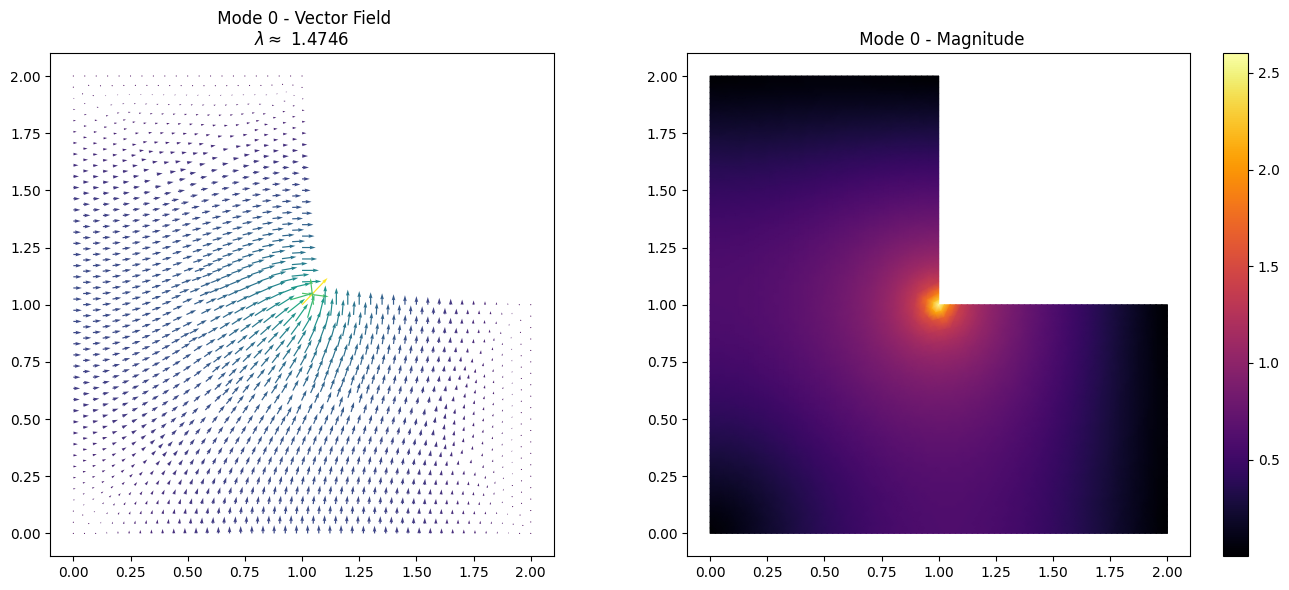

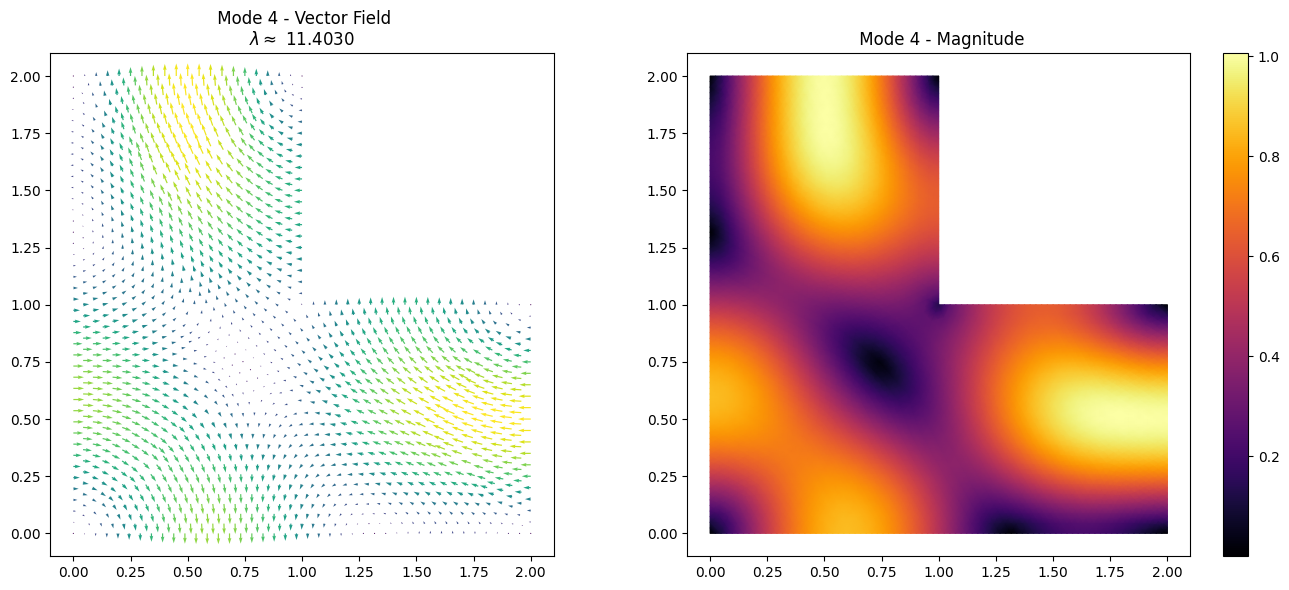

In [260]:
plot_eigenmode(solver, 0, title_prefix="")
plot_eigenmode(solver, 4, title_prefix="")

### True

In [89]:
def sum_of_squares_list(n_max, m_max):
    """
    Generates all n^2 + m^2 values for n from 0 to n_max and m from 0 to m_max.
    """
    return np.sort([n**2 + m**2 for n in range(n_max + 1) for m in range(m_max + 1)])

In [118]:
sum_of_squares_list(10,10)

array([  0,   1,   1,   2,   4,   4,   5,   5,   8,   9,   9,  10,  10,
        13,  13,  16,  16,  17,  17,  18,  20,  20,  25,  25,  25,  25,
        26,  26,  29,  29,  32,  34,  34,  36,  36,  37,  37,  40,  40,
        41,  41,  45,  45,  49,  49,  50,  50,  50,  52,  52,  53,  53,
        58,  58,  61,  61,  64,  64,  65,  65,  65,  65,  68,  68,  72,
        73,  73,  74,  74,  80,  80,  81,  81,  82,  82,  85,  85,  85,
        85,  89,  89,  90,  90,  97,  97,  98, 100, 100, 100, 100, 101,
       101, 104, 104, 106, 106, 109, 109, 113, 113, 116, 116, 117, 117,
       125, 125, 128, 130, 130, 136, 136, 145, 145, 149, 149, 162, 164,
       164, 181, 181, 200])